In [1]:
%load_ext autoreload
%autoreload 2

# **Feature Extraction**

El punto de partida del proyecto es un modelo que tome simplemente características numéricas de cada época (lapso de 30 segundos) e intente realizar una predicción a partir de estos. Para ello se realizó un proceso de *feature extraction* en el que, para cada época, se recortan las muestras de IHR y de acelerometría que caen en esa ventana de 30 s y se calculan las features descritas abajo.

Un punto importante sobre la **acelerometría**: features por cada eje (`x`, `y`, `z`) por separado dependen de la **orientación** del reloj (una persona acostada de lado vs. boca arriba da valores distintos aunque esté igual de quieta). Por eso todas las features de movimiento se calculan sobre la **magnitud del vector** $\|a\| = \sqrt{x^2+y^2+z^2}$, que es invariante a la orientación.

## Features *intra-época*

**IHR (Instantaneous Heart Rate):** Generamos features que son utilizadas en la práctica en el análisis de variabilidad de la frecuencia cardíaca (HRV, Heart Rate Variability) en el dominio del tiempo. Conceptos base:

- Intervalo *RR*: el tiempo (ms) entre dos latidos consecutivos, reconstruido como $\text{RR}=\tfrac{60.000\text{ms}}{\text{bpm}}$
- Intervalo *NN*: "nortmal-to-normal" interval, mismos intervalos que RR pero filtrando latidos irregulares (arritmias o errores del sensor). 

| Feature | Definición | Qué captura |
|---|---|---|
| `hr_mean` | Media del IHR. | Frecuencia cardíaca típica de la época. |
| `hr_std` | Desvío estándar (≈ SDNN=Standard Deviation of NN). | Variabilidad cardíaca global. |
| `hr_median` | Mediana. | Nivel central robusto ante outliers del IHR. |
| `hr_iqr` | Rango intercuartil (P75 − P25). | Dispersión robusta, alternativa a `std`. |
| `hr_rmssd` | "Root Means Square of Successive Differences". Raíz del promedio de las diferencias sucesivas al cuadrado, sobre intervalos RR (RR = 60000/bpm).| HRV de corto plazo / tono parasimpático. |
| `hr_pnn50` | "Percent of NN intervals differing by more than 50ms". Fracción de diferencias NN sucesivas mayores a 50 ms.| Otro índice de HRV vagal; complementa a `rmssd`. |
| `hr_slope` | Pendiente de la regresión lineal del IHR vs. tiempo dentro de la época. | Tendencia: aceleración o desaceleración cardíaca. |
| `hr_ptp` | Rango pico a pico. | Amplitud total de fluctuación; sensible a saltos de IHR. |
| `n_beats` | Cantidad de latidos válidos en la época. | Densidad de muestreo del IHR (no es uniforme); puede correlacionar con la calidad/estado. |

**Acelerometría (sobre la magnitud $\|a\|=\sqrt{x^2+y^2+z^2}$):**

*ENMO* (Euclidean Norm Minus One): se le resta $1g$ ($\approx 9.8m/s^2$) a la magnitud de la aceleración $\|a\|$ para quitar la gravedad y truncar a $>=0$. El estándar de oro en **actigrafía** para cuantificar movimiento neto.

$$
\text{ENMO} = \max (\|a\|- 1,\ 0)
$$

| Feature | Definición | Qué captura |
|---|---|---|
| `enmo_mean` | Media de ENMO. | Media de la aceleración dinámica neta. |
| `enmo_std` | Desvío estándar de ENMO. | Variabilidad del movimiento dentro de la época. |
| `acc_std` | Desvío estándar de $\|a\|$. | Cuánto fluctúa la magnitud; proxy de agitación. |
| `acc_ptp` | Rango pico a pico de $\|a\|$. | Amplitud máxima de movimiento. |
| `immobility_frac` | Fracción de muestras con $\|\,\|a\|-1\,\| < 0.05$ g. | Grado de inmovilidad; alto en sueño profundo, bajo en vigilia. |
| `jerk_std` | Desvío de la derivada de $\|a\|$. ($\text{jerk}=\tfrac{da}{dt}$: tasa de cambio de la aceleración) | Brusquedad del movimiento (sacudidas vs. deriva lenta). |

**Contexto del paciente:**

| Feature | Definición | Qué captura |
|---|---|---|
| `epoch_frac` | Índice de época normalizado (época / total de la noche). | Momento de la noche: la arquitectura del sueño depende fuertemente de él. |

## Features *inter-épocas*

Un modelo por época ignora que el sueño es altamente autocorrelacionado (las transiciones siguen reglas: no se salta de N3 a vigilia, REM sigue a NREM, etc.). Para inyectarle ese contexto temporal de forma explícita (lo que el LSTM hace implícitamente), sobre cada feature base se agregan, **dentro de cada noche** (respetando los límites entre noches):

- **`_lag1`, `_lag2`, `_lead1`, `_lead2`**: el valor de la feature 1 y 2 épocas antes y después (±30 y ±60 s de contexto).
- **`_delta1`**: diferencia con la época previa (`x[t] − x[t−1]`); un salto grande marca una transición de estado.
- **`_rmean`, `_rstd`**: media y desvío en una ventana móvil centrada de 5 épocas (±2), que suavizan el ruido y describen la dinámica local.

Además, una feature global de movimiento:

- **`epochs_since_move`**: cantidad de épocas transcurridas desde el último movimiento grande (ENMO medio > 0.05 g); proxy de qué tan asentado está el sueño.

Los valores en los bordes (lags/leads sin vecino) quedan como `NaN`, que **XGBoost maneja de forma nativa** aprendiendo una dirección por defecto. El dataset resultante (`data/epoch_features.csv`) tiene una fila por época, identificada por `subject`, `night` y `epoch`, con la etiqueta del experto (`expert_label`) como `label`. El recorte de cada noche a su ventana válida se aplica en memoria vía `EDA.load_night_clean`, sin modificar los CSV originales.


In [2]:
import sys
sys.path.append("..")

from src.feature_extraction import feature_extraction

c:\Users\agust\anaconda3\envs\pf_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os

# Solo se genera epoch_features.csv si aún no existe (en data_extraction/).
FEATURES_PATH = "../data_extraction/epoch_features.csv"
if os.path.exists(FEATURES_PATH):
    print(f"{FEATURES_PATH} ya existe; se omite la extracción.")
else:
    feature_extraction()

# **Split y entrenamiento del XGBoost**

Sobre el dataset de features entrenamos un **XGBoost** como modelo baseline (una predicción por época, sin secuencia).

**Partición de los datos.** Dividimos en **dev (80%)** y **test (20%)**, y dentro de dev en **train (80%)** y **validación (20%)**. La partición se hace **por paciente** (`GroupShuffleSplit` agrupando por `subject`), no por época: como las épocas de una misma noche/paciente están fuertemente correlacionadas, mezclarlas entre train y test produciría *fuga de información* y métricas optimistas. Agrupando por sujeto garantizamos que ningún paciente aparezca en más de un conjunto.

**Etiquetas.** El target es la etiqueta del experto (`label`). Descartamos las épocas marcadas como *Unknown* (clase 5). La validación se usa para *early stopping*.

**Evaluación.** Reportamos **F1-Score (macro)** y **Cohen's Kappa** sobre el test, comparando las predicciones contra dos referencias:
- **Expert**: la etiqueta del experto, que es el target con el que se entrenó.
- **Dreem**: el etiquetado automático de Dreem (basado en EEG). No es el target; mide cuánto coincide el modelo con una segunda anotación independiente.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv("../data_extraction/epoch_features.csv")

# descartamos las épocas Unknown (clase 5) del target
df = df[df['label'] != 5].reset_index(drop=True)

meta_cols = ['subject', 'night', 'epoch', 'label', 'dreem']
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols]
y = df['label'].values
groups = df['subject'].values

# dev (80%) / test (20%), agrupando por paciente para evitar fuga de información
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
dev_idx, test_idx = next(gss.split(X, y, groups))

X_dev, y_dev, g_dev = X.iloc[dev_idx], y[dev_idx], groups[dev_idx]
X_test, y_test = X.iloc[test_idx], y[test_idx]
dreem_test = df['dreem'].values[test_idx]

# dentro de dev: train (80%) / validación (20%), también por paciente
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, val_idx = next(gss_val.split(X_dev, y_dev, g_dev))

X_train, y_train = X_dev.iloc[tr_idx], y_dev[tr_idx]
X_val, y_val = X_dev.iloc[val_idx], y_dev[val_idx]

print(f"épocas  -> train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")
print(f"pacientes -> train: {len(np.unique(g_dev[tr_idx]))}  "
      f"val: {len(np.unique(g_dev[val_idx]))}  test: {len(np.unique(groups[test_idx]))}")

## Entrenamiento

In [11]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42,
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"mejor iteración (early stopping): {model.best_iteration}")


mejor iteración (early stopping): 159


## Desempeño

Evaluamos sobre el conjunto de **test** con `classification_report`, que produce dos bloques distintos.

**Métricas por clase** (una fila por etapa, calculadas *one-vs-rest*: "esta clase vs. todo lo demás"):

- **Precision** $= \tfrac{TP}{TP + FP}$: de las épocas que el modelo *predijo* como esa clase, qué fracción era correcta. Penaliza los **falsos positivos**.
- **Recall** (sensibilidad) $= \tfrac{TP}{TP + FN}$: de las épocas que *realmente eran* de esa clase, qué fracción detectó el modelo. Penaliza los **falsos negativos**.
- **F1-score** $= 2\cdot\tfrac{P\cdot R}{P + R}$: media armónica de precision y recall. Las resume en un número; es alto solo si **ambas** lo son.
- **Support**: cantidad de épocas reales de esa clase en el test. No es una métrica, sino el tamaño de la clase: evidencia el **desbalance** (N2 $\gg$ N1).

**Resúmenes globales** (las tres filas finales, que NO son clases sino formas de agregar):

- **Accuracy** $= \tfrac{\text{aciertos}}{\text{total}}$: un único número global. Engaña bajo desbalance: está dominada por la clase mayoritaria (N2).
- **Macro avg**: promedio **simple** de las métricas por clase (cada clase pesa igual, sin importar su support). Es la métrica honesta bajo desbalance: la pésima detección de N1 la castiga fuerte.
- **Weighted avg**: promedio **ponderado por support** (las clases grandes pesan más); queda más cerca de la accuracy.

Además reportamos **Cohen's Kappa**, $\kappa = \tfrac{p_o - p_e}{1 - p_e}$, donde $p_o$ es el acuerdo observado y $p_e$ el esperado por azar. $\kappa = 0$ es azar puro y $\kappa = 1$ acuerdo perfecto. Es la métrica estándar en *sleep staging* porque descuenta el acierto trivial sobre la clase mayoritaria.

Comparamos contra dos referencias:
- **Expert**: el target de entrenamiento (etiqueta del experto humano).
- **Dreem**: anotación automática basada en EEG, independiente; mide el acuerdo con una segunda fuente (enmascarando sus épocas *Unknown*).

In [12]:
from sklearn.metrics import f1_score, cohen_kappa_score, classification_report

y_pred = model.predict(X_test)

# vs Expert (target de entrenamiento)
f1_exp = f1_score(y_test, y_pred, average='macro')
kappa_exp = cohen_kappa_score(y_test, y_pred)

# vs Dreem (segunda anotación); descartamos épocas Dreem Unknown
mask = dreem_test != 5
f1_dreem = f1_score(dreem_test[mask], y_pred[mask], average='macro')
kappa_dreem = cohen_kappa_score(dreem_test[mask], y_pred[mask])

print(f"Expert  ->  F1-macro: {f1_exp:.3f}   Cohen's Kappa: {kappa_exp:.3f}")
print(f"Dreem   ->  F1-macro: {f1_dreem:.3f}   Cohen's Kappa: {kappa_dreem:.3f}")
print()
print("Reporte por clase (vs Expert):")
print(classification_report(y_test, y_pred, target_names=['Wake', 'N1', 'N2', 'N3', 'REM']))


Expert  ->  F1-macro: 0.471   Cohen's Kappa: 0.378
Dreem   ->  F1-macro: 0.466   Cohen's Kappa: 0.376

Reporte por clase (vs Expert):
              precision    recall  f1-score   support

        Wake       0.72      0.65      0.68      5655
          N1       0.25      0.01      0.01      3375
          N2       0.55      0.56      0.55     17365
          N3       0.64      0.50      0.56      9081
         REM       0.46      0.66      0.54     11951

    accuracy                           0.55     47427
   macro avg       0.52      0.48      0.47     47427
weighted avg       0.54      0.55      0.53     47427



## Comparación en 4 clases (Wake / Light / Deep / REM)

El estándar AASM define 5 etapas (Wake, N1, N2, N3, REM), que es como entrenamos el modelo. Sin embargo, el **paper original del dataset** reporta sus métricas sobre **4 clases**, colapsando los estadios NREM. Para comparar nuestros resultados de forma justa con esa referencia, reagrupamos:

| 4 clases | Reúne (5 clases) | Qué representa |
|---|---|---|
| **Wake** | Wake | Vigilia. |
| **Light** | N1 + N2 | Sueño NREM superficial: transición a dormir (N1) y sueño consolidado ligero (N2). |
| **Deep** | N3 | Sueño de ondas lentas (*slow-wave sleep*); el más reparador. |
| **REM** | REM | Sueño de movimientos oculares rápidos. |

**Por qué tiene sentido (más allá de comparar con el paper):** la frontera N1/N2 es la más ambigua incluso entre expertos humanos (κ inter-anotador bajo), y N1 es una clase chica y difícil — justamente la que nuestro modelo casi no detecta (f1 ≈ 0.01). Colapsar N1+N2 en *Light* elimina esa distinción ruidosa y mide qué tan bien separamos los **macro-estados** fisiológicos (vigilia / ligero / profundo / REM), que es lo clínicamente relevante para un wearable.

Importante: **no reentrenamos**. Tomamos las predicciones del modelo de 5 clases y aplicamos el mismo mapeo a predicción y target; las métricas de 4 clases son una vista agregada del mismo modelo.

In [13]:
map4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3}
names4 = ['Wake', 'Light', 'Deep', 'REM']
remap = np.vectorize(map4.get)

y_test4 = remap(y_test)
y_pred4 = remap(y_pred)

# vs Expert
f1_exp4 = f1_score(y_test4, y_pred4, average='macro')
kappa_exp4 = cohen_kappa_score(y_test4, y_pred4)

# vs Dreem (descartando épocas Dreem Unknown antes de reagrupar)
mask = dreem_test != 5
dreem_test4 = remap(dreem_test[mask])
y_pred4_d = remap(y_pred[mask])
f1_dreem4 = f1_score(dreem_test4, y_pred4_d, average='macro')
kappa_dreem4 = cohen_kappa_score(dreem_test4, y_pred4_d)

print(f"Expert (4 clases)  ->  F1-macro: {f1_exp4:.3f}   Cohen's Kappa: {kappa_exp4:.3f}")
print(f"Dreem  (4 clases)  ->  F1-macro: {f1_dreem4:.3f}   Cohen's Kappa: {kappa_dreem4:.3f}")
print()
print("Reporte por clase (vs Expert, 4 clases):")
print(classification_report(y_test4, y_pred4, target_names=names4))

Expert (4 clases)  ->  F1-macro: 0.587   Cohen's Kappa: 0.387
Dreem  (4 clases)  ->  F1-macro: 0.579   Cohen's Kappa: 0.381

Reporte por clase (vs Expert, 4 clases):
              precision    recall  f1-score   support

        Wake       0.72      0.65      0.68      5655
       Light       0.61      0.52      0.56     20740
        Deep       0.64      0.50      0.56      9081
         REM       0.46      0.66      0.54     11951

    accuracy                           0.57     47427
   macro avg       0.61      0.58      0.59     47427
weighted avg       0.59      0.57      0.57     47427



# **Feature Importance**

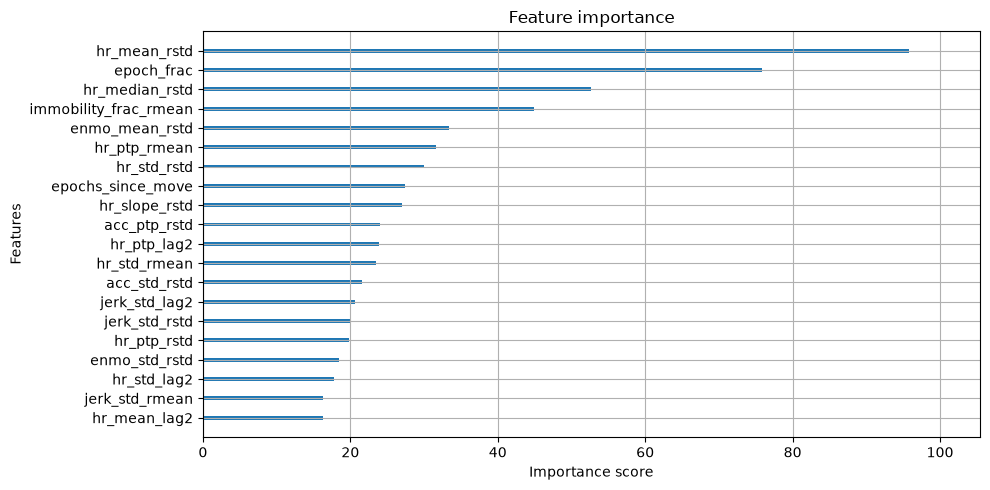

In [14]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

_, ax = plt.subplots(1,1,figsize=(10,5))
plot_importance(model, ax=ax, importance_type='gain', max_num_features=20, show_values=False)
plt.tight_layout()
plt.show()

## Feature importance con SHAP

El `gain` de arriba tiene un problema con nuestras features: están muy **correlacionadas** (cada feature base genera `_lag/_lead/_delta/_rmean/_rstd`, y hay pares casi redundantes como `hr_mean`/`hr_median`). XGBoost reparte el `gain` de forma arbitraria entre features correlacionadas, así que ese ranking puede subestimar señales reales.

**SHAP** (*SHapley Additive exPlanations*) atribuye a cada feature su contribución marginal promedio a la predicción, con base teórica en los valores de Shapley de teoría de juegos. Ventajas para nuestro caso:

- Reparte mejor el crédito entre features correlacionadas.
- Da la importancia **por clase** (Wake / N1 / N2 / N3 / REM), no solo global: permite verificar la hipótesis fisiológica (HRV pesa en REM/N3, movimiento en Wake).

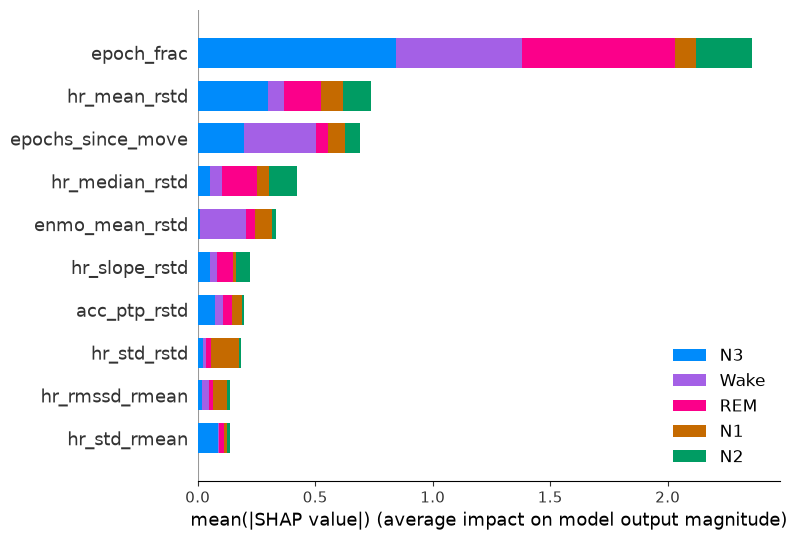

In [15]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
4
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

shap.summary_plot(shap_values, X_test, plot_type='bar', class_names=class_names, max_display=10, show=True)

En ambos enfoques (gain y SHAP) se destaca el índice de época (`epoch_frac`). Esto admite dos lecturas complementarias:

1. La arquitectura del sueño tiene una estructura temporal fuerte y aprendible a nivel poblacional: la etapa esperable depende mucho de la fracción de la noche (N3 domina el primer tercio, REM el último). El modelo explota este prior. Como contrapartida, apoyarse tanto en la posición (y no en la señal del reloj) implica un riesgo de peor generalización a noches atípicas, donde la arquitectura se desvía del promedio.
2. El posicionamiento temporal es clave, lo que sugiere que un modelo capaz de modelar dependencias temporales explícitas (LSTM/BiLSTM) sobre la secuencia de épocas debería mejorar las predicciones respecto del baseline por época.

Además, las features de contexto local (`_rmean`, `_rstd`, calculadas sobre ventanas de épocas vecinas) también figuran alto, lo que refuerza la misma idea: la información de las épocas adyacentes es relevante, y un modelo secuencial puede capturarla de forma nativa en lugar de tener que inyectarla a mano como features.